Step 1: Computing LAI (color-based Otsu on S channel)
  Processing train: 229 images
  Processing test: 57 images

Step 2: Computing LAI for Season 2
  Processing: 200 images

Step 3: Saving CSVs
  lai_labels_rgb.csv: 286 rows
  season2_lai.csv: 200 rows

LAI Statistics

[Train] n=229
  Range: 2.11 - 157.47 cm2
  Mean=49.29, Median=43.79, Std=35.20

[Test] n=57
  Range: 2.58 - 171.67 cm2
  Mean=51.67, Median=48.69, Std=38.22

[Paper Reference] test: 19 samples, 5-90 cm2, RMSE=1.859
  Flandria: n=96, range=2.11-75.10, mean=35.42, std=20.39
  Tiberius: n=94, range=4.01-171.67, mean=74.04, std=41.45
  Locarno: n=96, range=2.58-154.79, mean=40.34, std=29.25

[Season 2]
  Time 1: n=20, mean=4.67, std=3.71
  Time 2: n=20, mean=8.48, std=3.31
  Time 3: n=20, mean=16.20, std=4.91
  Time 4: n=20, mean=34.81, std=9.35
  Time 5: n=60, mean=63.54, std=16.29
  Time 6: n=60, mean=72.03, std=20.26

Generating visualizations...


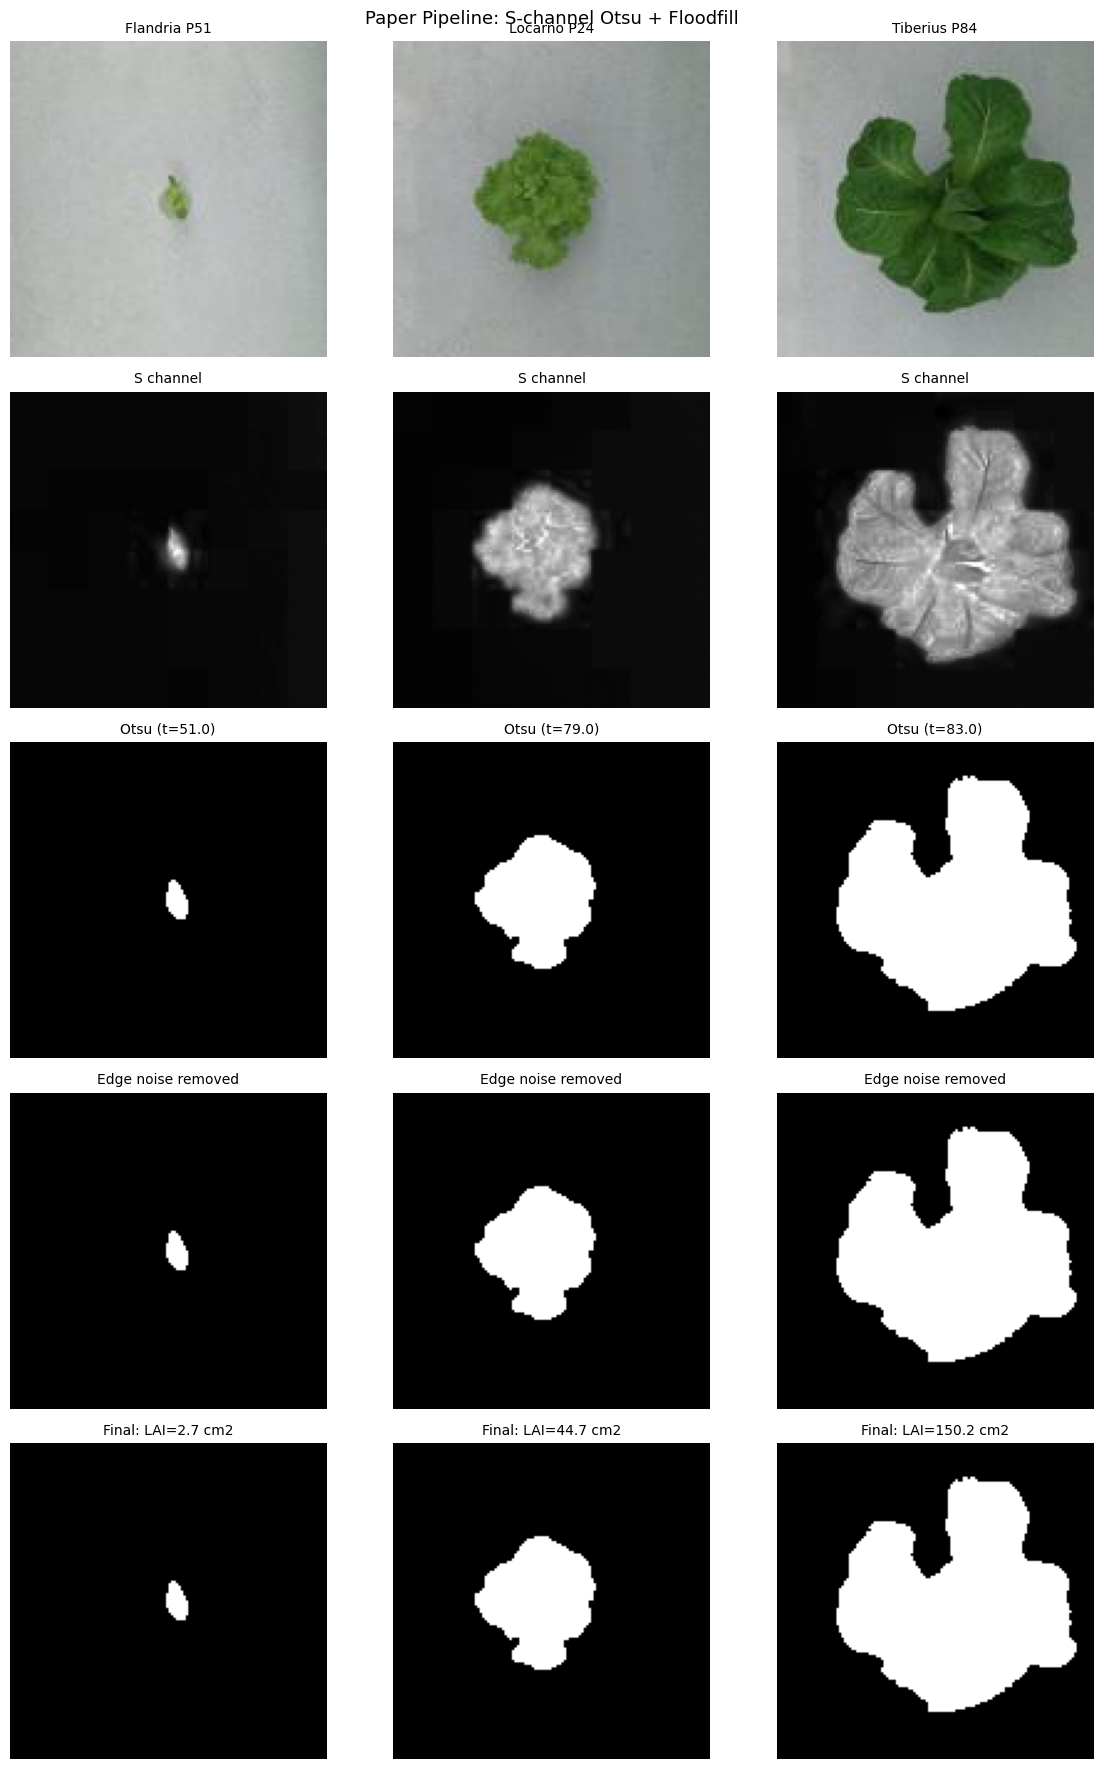

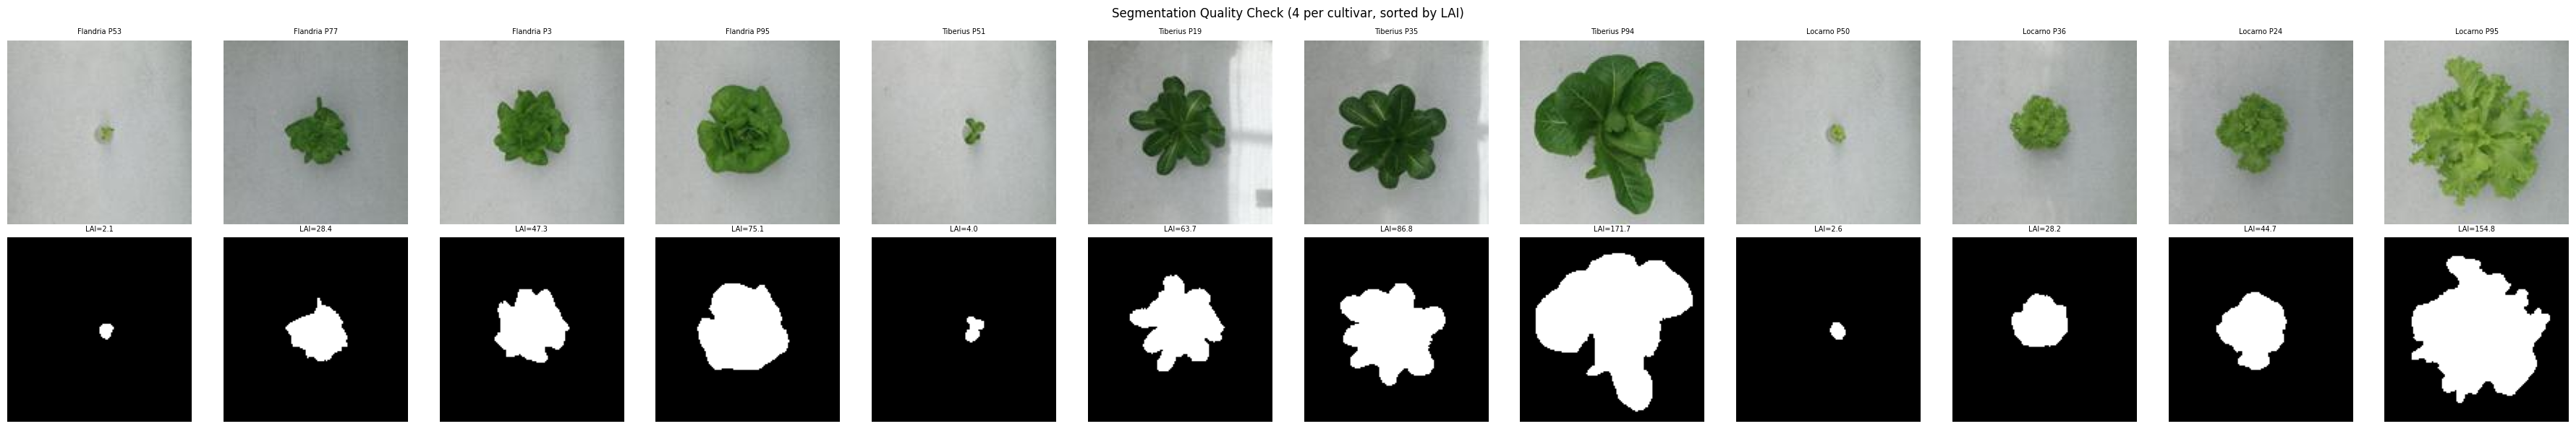

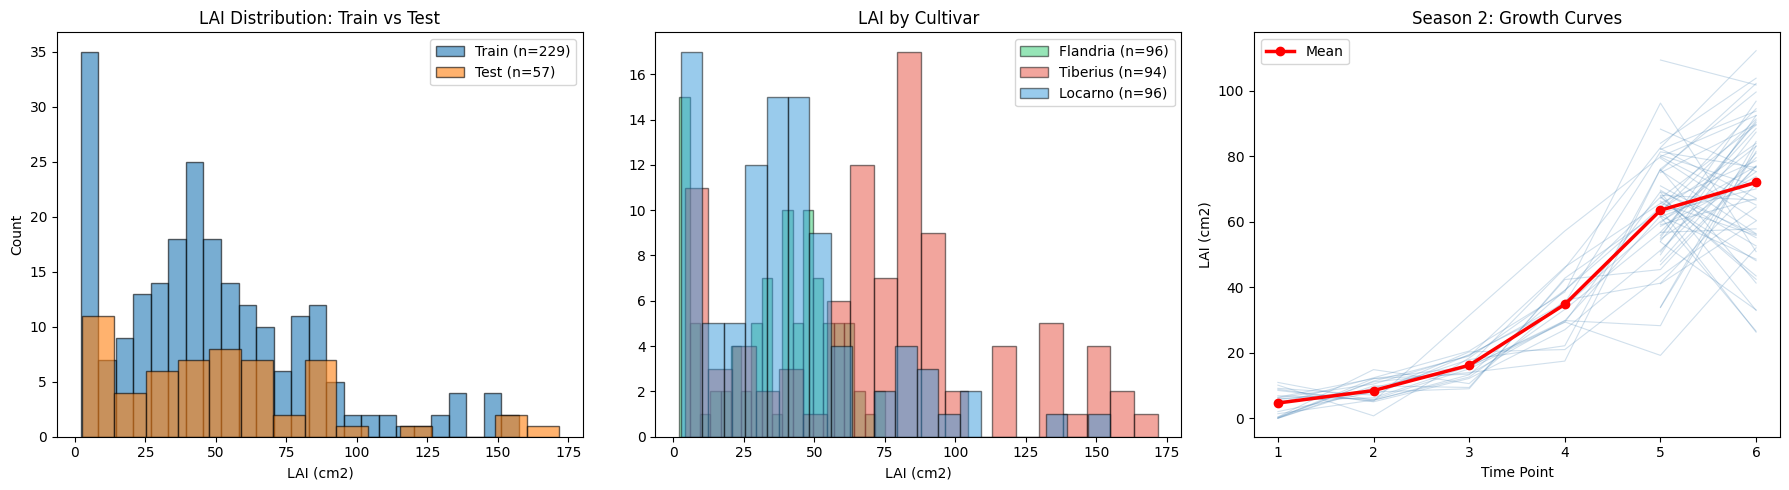

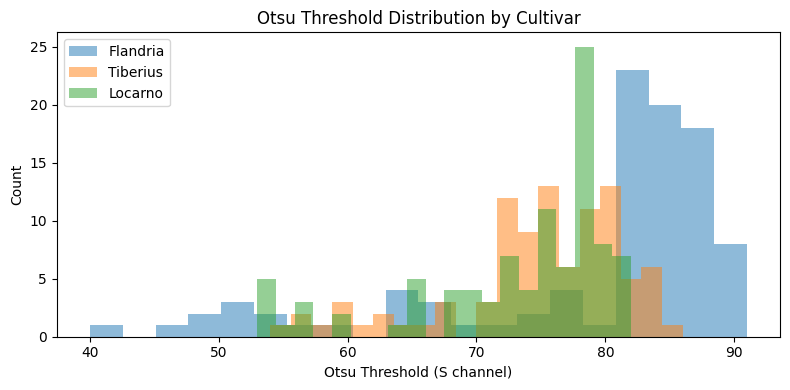


DONE!
  lai_labels_rgb.csv      - LAI for 286 images
  season2_lai.csv         - Season 2 LAI
  pipeline_steps.png      - Step-by-step pipeline
  segmentation_quality.png
  lai_distributions.png
  otsu_thresholds.png


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os, glob, re, csv
from pathlib import Path
from collections import defaultdict

# ============================================================
# 配置
# ============================================================
DATASET_ROOT = '/kaggle/input/datasets/minminandy/detect-dataset'
RGB_CNN_TRAIN = os.path.join(DATASET_ROOT, 'Datasets for building CNN/Datasets for building CNN/Training and validation')
RGB_CNN_TEST = os.path.join(DATASET_ROOT, 'Datasets for building CNN/Datasets for building CNN/test')
SEASON2_ROOT = os.path.join(DATASET_ROOT, 'Datasset of Season 2(1)/Datasset of Season 2')

IMG_SIZE = 128
PIXEL_AREA_CM2 = 2.605e-2
CULTIVAR_MAP = {1: 'Flandria', 2: 'Tiberius', 3: 'Locarno'}

# ============================================================
# Pipeline: 基于颜色信息的Otsu + Floodfill
# ============================================================
# 原文: "adaptive threshold method for the color information,
#         specifically the Otsu Threshold"
# 原文: "This is comparatively easy due to the color contrast
#         between the object i.e the plant and the background"
#
# 植株=绿色(高饱和度), 背景=灰白(低饱和度)
# 在HSV的S通道上做Otsu, 前景/背景方向确定:
#   S高=植株(白), S低=背景(黑) -> Otsu后植株自然是高值

def compute_lai_paper(img_bgr):
    """
    Paper pipeline using color information:
    Step 1: BGR -> HSV, 提取S通道 (饱和度)
    Step 2: Otsu threshold on S channel
    Step 3: Floodfill (边缘噪声 + 内部孔洞)
    Step 4: 像素计数 × 2.605e-2 = LAI (cm²)
    """
    # Step 1: 颜色信息提取
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    s_channel = hsv[:, :, 1]  # 饱和度: 绿色高, 灰白低

    # Step 2: Otsu on S channel
    # 植株(高S) -> 白, 背景(低S) -> 黑
    thresh_val, binary = cv2.threshold(s_channel, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # S通道上: 高饱和=植株=白色, 低饱和=背景=黑色
    # 方向天然正确, 不需要border check反转

    # Step 3a: Floodfill - 去除与边缘相连的白色噪声
    h, w = binary.shape
    binary_ff = binary.copy()
    flood_mask = np.zeros((h+2, w+2), np.uint8)
    for sx, sy in [(0,0), (w-1,0), (0,h-1), (w-1,h-1)]:
        if binary_ff[sy, sx] == 255:
            cv2.floodFill(binary_ff, flood_mask, (sx, sy), 0)

    # Step 3b: Floodfill - 填充植株内部小洞
    binary_inv = 255 - binary_ff
    flood_mask2 = np.zeros((h+2, w+2), np.uint8)
    for sx, sy in [(0,0), (w-1,0), (0,h-1), (w-1,h-1)]:
        if binary_inv[sy, sx] == 255:
            cv2.floodFill(binary_inv, flood_mask2, (sx, sy), 0)
    binary_filled = binary_ff.copy()
    binary_filled[binary_inv == 255] = 255

    # Step 4: 像素计数 -> LAI
    plant_pixels = np.sum(binary_filled > 0)
    lai_cm2 = plant_pixels * PIXEL_AREA_CM2

    return lai_cm2, binary_filled, thresh_val, binary, binary_ff


# ============================================================
# 处理所有RGB图像
# ============================================================
print("=" * 60)
print("Step 1: Computing LAI (color-based Otsu on S channel)")
print("=" * 60)

all_results = []

for split, dirpath in [('train', RGB_CNN_TRAIN), ('test', RGB_CNN_TEST)]:
    files = sorted(glob.glob(os.path.join(dirpath, '*.jpg')))
    print(f"  Processing {split}: {len(files)} images")

    for f in files:
        name = Path(f).stem
        parts = re.findall(r'\d+', name)
        cultivar_id = int(parts[0])
        plant_id = int(parts[1])

        img = cv2.imread(f)
        lai, mask, thresh, _, _ = compute_lai_paper(img)

        all_results.append({
            'split': split,
            'filename': name + '.jpg',
            'cultivar_id': cultivar_id,
            'cultivar_name': CULTIVAR_MAP.get(cultivar_id, f'Unknown_{cultivar_id}'),
            'plant_id': plant_id,
            'lai_cm2': round(lai, 4),
            'plant_pixels': int(np.sum(mask > 0)),
            'otsu_threshold': int(thresh),
        })

# ============================================================
# 处理 Season 2
# ============================================================
print("\n" + "=" * 60)
print("Step 2: Computing LAI for Season 2")
print("=" * 60)

s2_results = []
s2_files = sorted(glob.glob(os.path.join(SEASON2_ROOT, '*.jpg')))
print(f"  Processing: {len(s2_files)} images")

for f in s2_files:
    name = Path(f).stem
    parts = re.findall(r'\d+', name)
    time_id = int(parts[0])
    plant_id = int(parts[1])

    img = cv2.imread(f)
    lai, mask, thresh, _, _ = compute_lai_paper(img)

    s2_results.append({
        'filename': name + '.jpg',
        'time_id': time_id,
        'plant_id': plant_id,
        'lai_cm2': round(lai, 4),
        'plant_pixels': int(np.sum(mask > 0)),
        'otsu_threshold': int(thresh),
    })

# ============================================================
# 保存CSV
# ============================================================
print("\n" + "=" * 60)
print("Step 3: Saving CSVs")
print("=" * 60)

csv_rgb = 'lai_labels_rgb.csv'
with open(csv_rgb, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=list(all_results[0].keys()))
    w.writeheader()
    w.writerows(all_results)
print(f"  {csv_rgb}: {len(all_results)} rows")

csv_s2 = 'season2_lai.csv'
with open(csv_s2, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=list(s2_results[0].keys()))
    w.writeheader()
    w.writerows(s2_results)
print(f"  {csv_s2}: {len(s2_results)} rows")

# ============================================================
# 统计
# ============================================================
print("\n" + "=" * 60)
print("LAI Statistics")
print("=" * 60)

train_lais = [r['lai_cm2'] for r in all_results if r['split'] == 'train']
test_lais = [r['lai_cm2'] for r in all_results if r['split'] == 'test']

print(f"\n[Train] n={len(train_lais)}")
print(f"  Range: {min(train_lais):.2f} - {max(train_lais):.2f} cm2")
print(f"  Mean={np.mean(train_lais):.2f}, Median={np.median(train_lais):.2f}, Std={np.std(train_lais):.2f}")

print(f"\n[Test] n={len(test_lais)}")
print(f"  Range: {min(test_lais):.2f} - {max(test_lais):.2f} cm2")
print(f"  Mean={np.mean(test_lais):.2f}, Median={np.median(test_lais):.2f}, Std={np.std(test_lais):.2f}")

print(f"\n[Paper Reference] test: 19 samples, 5-90 cm2, RMSE=1.859")

for cid in [1, 2, 3]:
    lais_c = [r['lai_cm2'] for r in all_results if r['cultivar_id'] == cid]
    print(f"  {CULTIVAR_MAP[cid]}: n={len(lais_c)}, "
          f"range={min(lais_c):.2f}-{max(lais_c):.2f}, "
          f"mean={np.mean(lais_c):.2f}, std={np.std(lais_c):.2f}")

print(f"\n[Season 2]")
for t in sorted(set(r['time_id'] for r in s2_results)):
    t_lais = [r['lai_cm2'] for r in s2_results if r['time_id'] == t]
    print(f"  Time {t}: n={len(t_lais)}, mean={np.mean(t_lais):.2f}, std={np.std(t_lais):.2f}")

# ============================================================
# 可视化1: Pipeline逐步展示
# ============================================================
print("\nGenerating visualizations...")

# 选3个样本: 小/中/大LAI
sorted_all = sorted(all_results, key=lambda x: x['lai_cm2'])
sample_picks = [sorted_all[5],
                sorted_all[len(sorted_all)//2],
                sorted_all[-5]]

fig, axes = plt.subplots(5, 3, figsize=(12, 18))
step_labels = ['Original', 'S Channel (HSV)', 'Otsu on S', 'Floodfill (edge)', 'Final (hole filled)']

for col, r in enumerate(sample_picks):
    dirpath = RGB_CNN_TRAIN if r['split'] == 'train' else RGB_CNN_TEST
    fpath = os.path.join(dirpath, r['filename'])
    img = cv2.imread(fpath)

    lai, final_mask, thresh, binary_otsu, binary_ff = compute_lai_paper(img)

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    s_ch = hsv[:, :, 1]

    axes[0, col].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0, col].set_title(f"{r['cultivar_name']} P{r['plant_id']}", fontsize=10)

    axes[1, col].imshow(s_ch, cmap='gray')
    axes[1, col].set_title(f"S channel", fontsize=10)

    axes[2, col].imshow(binary_otsu, cmap='gray')
    axes[2, col].set_title(f"Otsu (t={thresh})", fontsize=10)

    axes[3, col].imshow(binary_ff, cmap='gray')
    axes[3, col].set_title("Edge noise removed", fontsize=10)

    axes[4, col].imshow(final_mask, cmap='gray')
    axes[4, col].set_title(f"Final: LAI={lai:.1f} cm2", fontsize=10)

for i, label in enumerate(step_labels):
    axes[i, 0].set_ylabel(label, fontsize=9, rotation=0, labelpad=90, va='center')

for ax in axes.flat:
    ax.axis('off')

plt.suptitle('Paper Pipeline: S-channel Otsu + Floodfill', fontsize=13)
plt.tight_layout()
plt.savefig('pipeline_steps.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 可视化2: 分割质量检查 (每品种4个)
# ============================================================
fig, axes = plt.subplots(2, 12, figsize=(36, 6))

sample_idx = 0
for cid in [1, 2, 3]:
    cid_results = sorted([r for r in all_results if r['cultivar_id'] == cid],
                         key=lambda x: x['lai_cm2'])
    indices = np.linspace(0, len(cid_results)-1, 4).astype(int)

    for idx in indices:
        r = cid_results[idx]
        dirpath = RGB_CNN_TRAIN if r['split'] == 'train' else RGB_CNN_TEST
        fpath = os.path.join(dirpath, r['filename'])

        img = cv2.imread(fpath)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        _, mask, _, _, _ = compute_lai_paper(img)

        axes[0, sample_idx].imshow(img_rgb)
        axes[0, sample_idx].set_title(f"{CULTIVAR_MAP[cid]} P{r['plant_id']}", fontsize=7)
        axes[0, sample_idx].axis('off')

        axes[1, sample_idx].imshow(mask, cmap='gray')
        axes[1, sample_idx].set_title(f"LAI={r['lai_cm2']:.1f}", fontsize=7)
        axes[1, sample_idx].axis('off')

        sample_idx += 1

plt.suptitle('Segmentation Quality Check (4 per cultivar, sorted by LAI)', fontsize=12)
plt.tight_layout()
plt.savefig('segmentation_quality.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 可视化3: LAI分布 + 生长曲线
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Train/Test分布
axes[0].hist(train_lais, bins=25, alpha=0.6, label=f'Train (n={len(train_lais)})', edgecolor='black')
axes[0].hist(test_lais, bins=15, alpha=0.6, label=f'Test (n={len(test_lais)})', edgecolor='black')
axes[0].set_xlabel('LAI (cm2)')
axes[0].set_ylabel('Count')
axes[0].set_title('LAI Distribution: Train vs Test')
axes[0].legend()

# 按品种
colors = ['#2ecc71', '#e74c3c', '#3498db']
for i, cid in enumerate([1, 2, 3]):
    lais_c = [r['lai_cm2'] for r in all_results if r['cultivar_id'] == cid]
    axes[1].hist(lais_c, bins=20, alpha=0.5, color=colors[i],
                 label=f"{CULTIVAR_MAP[cid]} (n={len(lais_c)})", edgecolor='black')
axes[1].set_xlabel('LAI (cm2)')
axes[1].set_title('LAI by Cultivar')
axes[1].legend()

# Season 2 生长曲线
s2_by_plant = defaultdict(list)
for r in s2_results:
    s2_by_plant[r['plant_id']].append((r['time_id'], r['lai_cm2']))

for pid, points in sorted(s2_by_plant.items()):
    points.sort()
    axes[2].plot([p[0] for p in points], [p[1] for p in points],
                 alpha=0.25, color='steelblue', linewidth=0.8)

mean_by_time = defaultdict(list)
for r in s2_results:
    mean_by_time[r['time_id']].append(r['lai_cm2'])
times_sorted = sorted(mean_by_time.keys())
means = [np.mean(mean_by_time[t]) for t in times_sorted]
axes[2].plot(times_sorted, means, 'r-o', linewidth=2.5, markersize=6, label='Mean')
axes[2].set_xlabel('Time Point')
axes[2].set_ylabel('LAI (cm2)')
axes[2].set_title('Season 2: Growth Curves')
axes[2].legend()

plt.tight_layout()
plt.savefig('lai_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 可视化4: Otsu阈值分布
# ============================================================
fig, ax = plt.subplots(figsize=(8, 4))
for cid in [1, 2, 3]:
    t_c = [r['otsu_threshold'] for r in all_results if r['cultivar_id'] == cid]
    ax.hist(t_c, bins=20, alpha=0.5, label=CULTIVAR_MAP[cid])
ax.set_xlabel('Otsu Threshold (S channel)')
ax.set_ylabel('Count')
ax.set_title('Otsu Threshold Distribution by Cultivar')
ax.legend()
plt.tight_layout()
plt.savefig('otsu_thresholds.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 60)
print("DONE!")
print("  lai_labels_rgb.csv      - LAI for 286 images")
print("  season2_lai.csv         - Season 2 LAI")
print("  pipeline_steps.png      - Step-by-step pipeline")
print("  segmentation_quality.png")
print("  lai_distributions.png")
print("  otsu_thresholds.png")
print("=" * 60)

Device: cuda
Train 208 / Val 21 / Test 57
LAI norm: mean=48.67, std=34.66


model.safetensors:   0%|          | 0.00/10.2M [00:00<?, ?B/s]

Backbone feature dim: 1024
Params: 1.59M
[  1/80] train_loss=0.3374(reg=0.1974,cls=0.8978) | val_RMSE=21.14 MAE=18.17 R²=0.716 Acc=0.619
[ 10/80] train_loss=0.0683(reg=0.0418,cls=0.1743) | val_RMSE=7.14 MAE=6.10 R²=0.968 Acc=0.857
[ 20/80] train_loss=0.0324(reg=0.0176,cls=0.0914) | val_RMSE=5.98 MAE=4.14 R²=0.977 Acc=0.857
[ 30/80] train_loss=0.0126(reg=0.0117,cls=0.0161) | val_RMSE=6.59 MAE=5.34 R²=0.972 Acc=0.952
[ 40/80] train_loss=0.0062(reg=0.0069,cls=0.0038) | val_RMSE=5.33 MAE=3.88 R²=0.982 Acc=1.000
[ 50/80] train_loss=0.0047(reg=0.0042,cls=0.0064) | val_RMSE=5.59 MAE=3.67 R²=0.980 Acc=1.000
Early stop at epoch 56

TEST RESULTS
  RMSE: 6.56 cm²
  MAE:  3.87 cm²
  R²:   0.9705
  Acc:  0.965
  [Paper: RMSE=1.859]


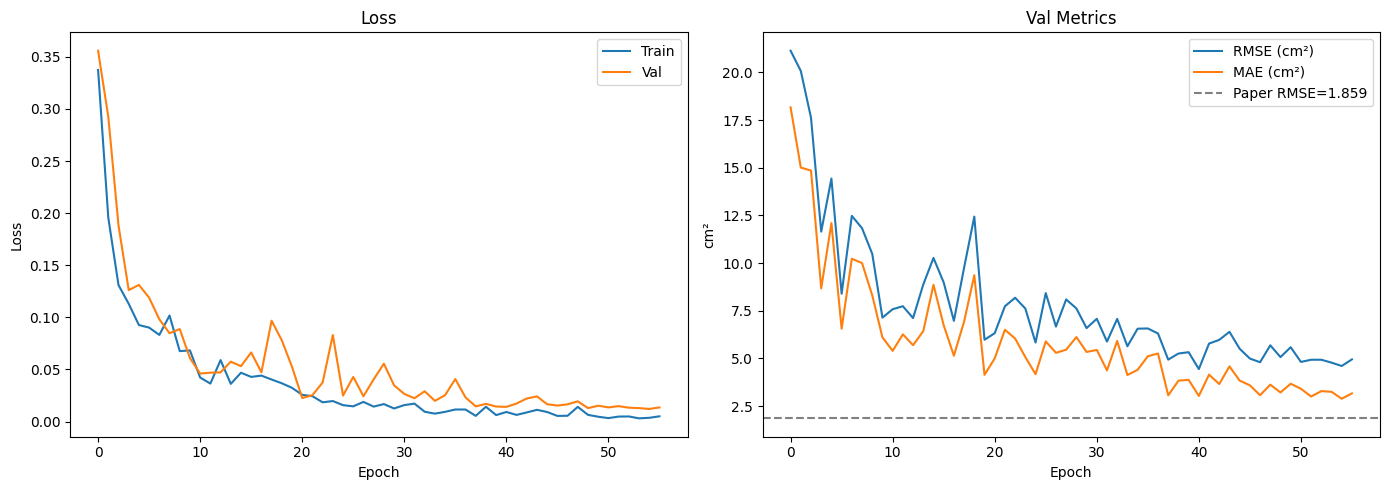

In [ ]:
import os, csv, copy, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import timm
import matplotlib.pyplot as plt
from collections import defaultdict

# ============================================================
# Config
# ============================================================
DATA_ROOT = '/kaggle/input/datasets/minminandy/detect-dataset/Datasets for building CNN/Datasets for building CNN'
LABEL_CSV = '/kaggle/working/lai_labels_rgb.csv'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

IMG_SIZE = 128
BATCH_SIZE = 16
EPOCHS = 80
LR_BACKBONE = 1e-4
LR_HEAD = 5e-4
WEIGHT_DECAY = 1e-4
ALPHA_REG = 0.8
ALPHA_CLS = 0.2
VAL_RATIO = 0.1
PATIENCE = 15

# ============================================================
# Dataset
# ============================================================
class LettuceDataset(Dataset):
    def __init__(self, records, data_root, transform, lai_mean, lai_std):
        self.records = records
        self.data_root = data_root
        self.transform = transform
        self.lai_mean = lai_mean
        self.lai_std = lai_std

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]
        subdir = 'Training and validation' if r['split'] == 'train' else 'test'
        img = Image.open(os.path.join(self.data_root, subdir, r['filename'])).convert('RGB')
        img = self.transform(img)
        lai = torch.tensor((r['lai_cm2'] - self.lai_mean) / self.lai_std, dtype=torch.float32)
        cls = torch.tensor(r['cultivar_id'] - 1, dtype=torch.long)
        return img, lai, cls

def load_csv(path):
    with open(path) as f:
        return [{'split': r['split'], 'filename': r['filename'],
                 'cultivar_id': int(r['cultivar_id']), 'lai_cm2': float(r['lai_cm2'])}
                for r in csv.DictReader(f)]

def build_loaders():
    records = load_csv(LABEL_CSV)
    train_all = [r for r in records if r['split'] == 'train']
    test_recs = [r for r in records if r['split'] == 'test']

    # stratified split
    np.random.shuffle(train_all)
    by_c = defaultdict(list)
    for r in train_all:
        by_c[r['cultivar_id']].append(r)
    train_recs, val_recs = [], []
    for recs in by_c.values():
        n = max(1, int(len(recs) * VAL_RATIO))
        val_recs.extend(recs[:n])
        train_recs.extend(recs[n:])

    lai_mean = np.mean([r['lai_cm2'] for r in train_recs])
    lai_std = np.std([r['lai_cm2'] for r in train_recs])

    train_tf = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize([.485,.456,.406], [.229,.224,.225]),
    ])
    eval_tf = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([.485,.456,.406], [.229,.224,.225]),
    ])

    kw = dict(num_workers=2, pin_memory=True)
    train_dl = DataLoader(LettuceDataset(train_recs, DATA_ROOT, train_tf, lai_mean, lai_std),
                          batch_size=BATCH_SIZE, shuffle=True, drop_last=True, **kw)
    val_dl = DataLoader(LettuceDataset(val_recs, DATA_ROOT, eval_tf, lai_mean, lai_std),
                        batch_size=BATCH_SIZE, shuffle=False, **kw)
    test_dl = DataLoader(LettuceDataset(test_recs, DATA_ROOT, eval_tf, lai_mean, lai_std),
                         batch_size=BATCH_SIZE, shuffle=False, **kw)

    print(f"Train {len(train_recs)} / Val {len(val_recs)} / Test {len(test_recs)}")
    print(f"LAI norm: mean={lai_mean:.2f}, std={lai_std:.2f}")
    return train_dl, val_dl, test_dl, lai_mean, lai_std

# ============================================================
# Model
# ============================================================
class MultiTaskNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model('mobilenetv3_small_100', pretrained=True, num_classes=0)
        with torch.no_grad():
            d = self.backbone(torch.randn(1, 3, IMG_SIZE, IMG_SIZE)).shape[1]
        print(f"Backbone feature dim: {d}")
        self.cls_head = nn.Linear(d, 3)
        self.reg_head = nn.Sequential(nn.Linear(d, 64), nn.ReLU(), nn.Linear(64, 1))

    def forward(self, x):
        f = self.backbone(x)
        return self.cls_head(f), self.reg_head(f).squeeze(-1)

# ============================================================
# Train / Eval
# ============================================================
def train_epoch(model, loader, optimizer):
    model.train()
    losses, reg_l, cls_l = [], [], []
    for imgs, lais, cls in loader:
        imgs, lais, cls = imgs.to(DEVICE), lais.to(DEVICE), cls.to(DEVICE)
        logits, pred = model(imgs)
        l_reg = F.smooth_l1_loss(pred, lais)
        l_cls = F.cross_entropy(logits, cls)
        loss = ALPHA_REG * l_reg + ALPHA_CLS * l_cls
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        losses.append(loss.item())
        reg_l.append(l_reg.item())
        cls_l.append(l_cls.item())
    return np.mean(losses), np.mean(reg_l), np.mean(cls_l)

@torch.no_grad()
def evaluate(model, loader, lai_mean, lai_std):
    model.eval()
    preds, targets, correct, total = [], [], 0, 0
    reg_l, cls_l = [], []
    for imgs, lais, cls in loader:
        imgs, lais, cls = imgs.to(DEVICE), lais.to(DEVICE), cls.to(DEVICE)
        logits, pred = model(imgs)
        reg_l.append(F.smooth_l1_loss(pred, lais).item())
        cls_l.append(F.cross_entropy(logits, cls).item())
        correct += (logits.argmax(1) == cls).sum().item()
        total += imgs.size(0)
        # 反标准化
        preds.extend((pred.cpu().numpy() * lai_std + lai_mean).tolist())
        targets.extend((lais.cpu().numpy() * lai_std + lai_mean).tolist())

    p, t = np.array(preds), np.array(targets)
    rmse = np.sqrt(np.mean((p - t) ** 2))
    mae = np.mean(np.abs(p - t))
    r2 = 1 - np.sum((t - p)**2) / (np.sum((t - np.mean(t))**2) + 1e-8)
    total_loss = ALPHA_REG * np.mean(reg_l) + ALPHA_CLS * np.mean(cls_l)
    return {'loss': total_loss, 'reg_loss': np.mean(reg_l), 'cls_loss': np.mean(cls_l),
            'rmse': rmse, 'mae': mae, 'r2': r2, 'acc': correct / total,
            'preds': p, 'targets': t}

# ============================================================
# Main
# ============================================================
print(f"Device: {DEVICE}")
train_dl, val_dl, test_dl, lai_mean, lai_std = build_loaders()

model = MultiTaskNet().to(DEVICE)
params = sum(p.numel() for p in model.parameters())
print(f"Params: {params/1e6:.2f}M")

optimizer = torch.optim.AdamW([
    {'params': model.backbone.parameters(), 'lr': LR_BACKBONE},
    {'params': model.cls_head.parameters(), 'lr': LR_HEAD},
    {'params': model.reg_head.parameters(), 'lr': LR_HEAD},
], weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

# history
hist = {'train_loss': [], 'train_reg': [], 'train_cls': [],
        'val_loss': [], 'val_reg': [], 'val_cls': [],
        'val_rmse': [], 'val_mae': [], 'val_r2': [], 'val_acc': []}

best_rmse = float('inf')
best_state = None
no_improve = 0

for epoch in range(EPOCHS):
    t_loss, t_reg, t_cls = train_epoch(model, train_dl, optimizer)
    v = evaluate(model, val_dl, lai_mean, lai_std)
    scheduler.step()

    hist['train_loss'].append(t_loss)
    hist['train_reg'].append(t_reg)
    hist['train_cls'].append(t_cls)
    hist['val_loss'].append(v['loss'])
    hist['val_reg'].append(v['reg_loss'])
    hist['val_cls'].append(v['cls_loss'])
    hist['val_rmse'].append(v['rmse'])
    hist['val_mae'].append(v['mae'])
    hist['val_r2'].append(v['r2'])
    hist['val_acc'].append(v['acc'])

    if v['rmse'] < best_rmse:
        best_rmse = v['rmse']
        best_state = copy.deepcopy(model.state_dict())
        no_improve = 0
    else:
        no_improve += 1

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"[{epoch+1:3d}/{EPOCHS}] "
              f"train_loss={t_loss:.4f}(reg={t_reg:.4f},cls={t_cls:.4f}) | "
              f"val_RMSE={v['rmse']:.2f} MAE={v['mae']:.2f} R²={v['r2']:.3f} Acc={v['acc']:.3f}")

    if no_improve >= PATIENCE:
        print(f"Early stop at epoch {epoch+1}")
        break

# Test
model.load_state_dict(best_state)
test = evaluate(model, test_dl, lai_mean, lai_std)
print(f"\n{'='*50}")
print(f"TEST RESULTS")
print(f"  RMSE: {test['rmse']:.2f} cm²")
print(f"  MAE:  {test['mae']:.2f} cm²")
print(f"  R²:   {test['r2']:.4f}")
print(f"  Acc:  {test['acc']:.3f}")
print(f"  [Paper: RMSE=1.859]")
print(f"{'='*50}")

torch.save({'state_dict': best_state, 'lai_mean': lai_mean, 'lai_std': lai_std,
            'test_metrics': {k: v for k, v in test.items() if k not in ['preds','targets']}},
           'model_multitask.pth')

# ============================================================
# Plot
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(hist['train_loss'], label='Train')
axes[0].plot(hist['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss'); axes[0].legend()

# Metrics
axes[1].plot(hist['val_rmse'], label='RMSE (cm²)')
axes[1].plot(hist['val_mae'], label='MAE (cm²)')
axes[1].axhline(y=1.859, color='gray', linestyle='--', label='Paper RMSE=1.859')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('cm²')
axes[1].set_title('Val Metrics'); axes[1].legend()

plt.tight_layout()
plt.savefig('training_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Season 2 results
s2_df = pd.read_csv('season2_lai.csv')

# Calculate mean and std for each time point
stats = s2_df.groupby('time_id')['lai_cm2'].agg(['mean', 'std']).reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=s2_df, x='time_id', y='lai_cm2', units='plant_id',
             estimator=None, color='gray', alpha=0.3, label='Individual Plants')
plt.errorbar(stats['time_id'], stats['mean'], yerr=stats['std'],
             fmt='-o', color='red', linewidth=3, capsize=5, label='Mean Growth Trend')

plt.title('Season 2: Lettuce Growth Trend (LAI over Time)')
plt.xlabel('Time Point (Measurement Interval)')
plt.ylabel('LAI (cm²)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
test_records = [r for r in load_csv(LABEL_CSV) if r['split'] == 'test']
for cid, name in [(1,'Flandria'), (2,'Tiberius'), (3,'Locarno')]:
    mask = np.array([r['cultivar_id'] == cid for r in test_records])
    if mask.sum() > 0:
        rmse_c = np.sqrt(np.mean((test['preds'][mask] - test['targets'][mask])**2))
        mae_c = np.mean(np.abs(test['preds'][mask] - test['targets'][mask]))
        print(f"{name}: n={mask.sum()}, RMSE={rmse_c:.2f}, MAE={mae_c:.2f}")

Flandria: n=19, RMSE=3.15, MAE=2.17
Tiberius: n=19, RMSE=7.47, MAE=5.43
Locarno: n=19, RMSE=7.96, MAE=4.01
